In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [282]:
netflix_df = pd.read_csv("C:/Users/HELLO/Desktop/Data Science/data/netflix1.csv")

In [283]:
netflix_df.head(10)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
5,s9,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,9/24/2021,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
6,s10,Movie,The Starling,Theodore Melfi,United States,9/24/2021,2021,PG-13,104 min,"Comedies, Dramas"
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,5/1/2021,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu..."
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,9/23/2021,2021,TV-MA,127 min,"Dramas, International Movies"
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,5/1/2021,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals"


In [284]:
netflix_df.shape

(8790, 10)

In [285]:
netflix_df["listed_in"].dtype

dtype('O')

In [286]:
netflix_df["type"].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

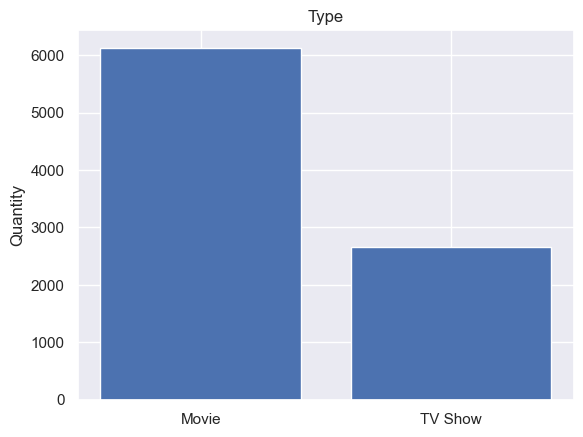

In [289]:
#bar chart counts the number of Movie and TV Show
netflix_type_count = {"Movie": 6126,
                     "TV Show": 2664}
fig, ax = plt.subplots()
ax.bar(netflix_type_count.keys(), netflix_type_count.values())
ax.set(title = "Type",
      ylabel = "Quantity");

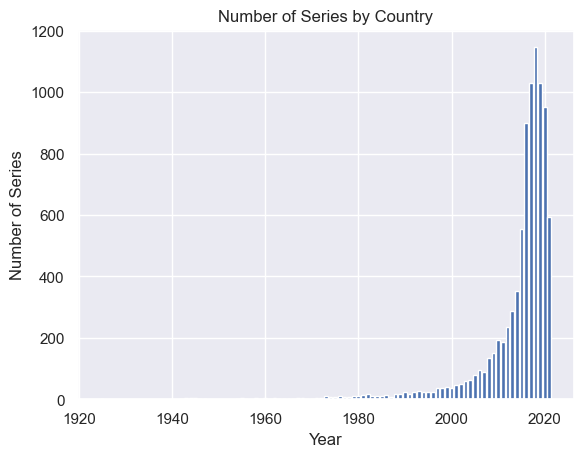

<Figure size 20000x1000 with 0 Axes>

In [291]:
#number of series base on release year
netflix_df["release_year"].value_counts()
netflix_df["quantity"]=1
#netflix_df.head(10)
netflix_release_year_df = netflix_df.groupby("release_year")["quantity"].sum().reset_index()
#netflix_release_year_df["quantity"].sort_values(ascending = False)
#netflix_release_year_df.head(5)
fig, ax = plt.subplots();
plt.figure(figsize = (200,10));
ax.bar(netflix_release_year_df["release_year"], netflix_release_year_df["quantity"]);
ax.set(title = "Number of Series by Country",
      ylabel = "Number of Series",
      xlabel = "Year");

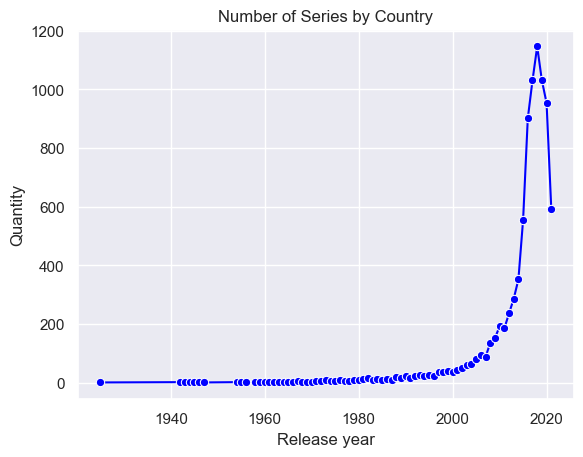

In [295]:
#number of series base on release year_LINE_PLOT
ax = sns.lineplot(data = netflix_release_year_df,
            x = "release_year",
            y = "quantity",
            marker = 'o',
            color = "Blue");
#netflix_release_year_df.head(10)
ax.set(title = "Number of Series by Country",
      xlabel = "Release year",
      ylabel = "Quantity");
#ax.set_title = ("Number of Series by Country")

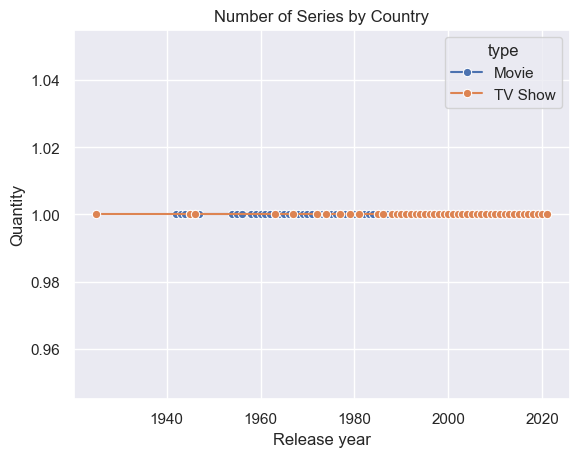

In [296]:
#Check
ax = sns.lineplot(data = netflix_df,
            x = "release_year",
            y = "quantity",
            hue = "type",
            marker = 'o',
            color = "Blue");
#netflix_release_year_df.head(10)
ax.set(title = "Number of Series by Country",
      xlabel = "Release year",
      ylabel = "Quantity");
#ax.set_title = ("Number of Series by Country")

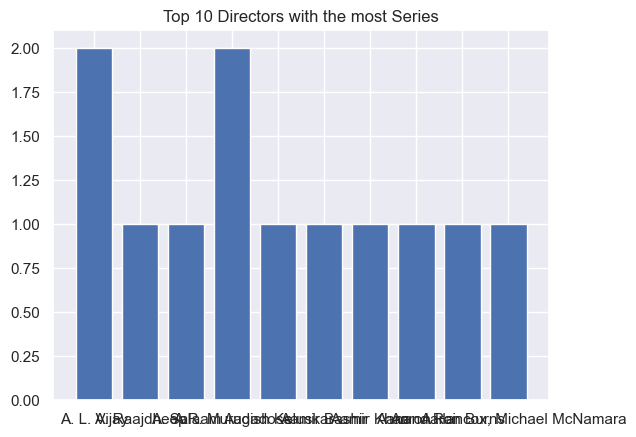

In [297]:
#Top 10 directors who have the most number of Series
netflix_directors_df = (netflix_df.groupby("director")["quantity"].sum().reset_index())
netflix_directors_df = netflix_directors_df.head(10)
fig, ax = plt.subplots()
#plt.figure(figsize = (1000,500))
plt.bar(netflix_directors_df["director"], netflix_directors_df["quantity"]);
#netflix_directors_df.head(10)
plt.title("Top 10 Directors with the most Series");

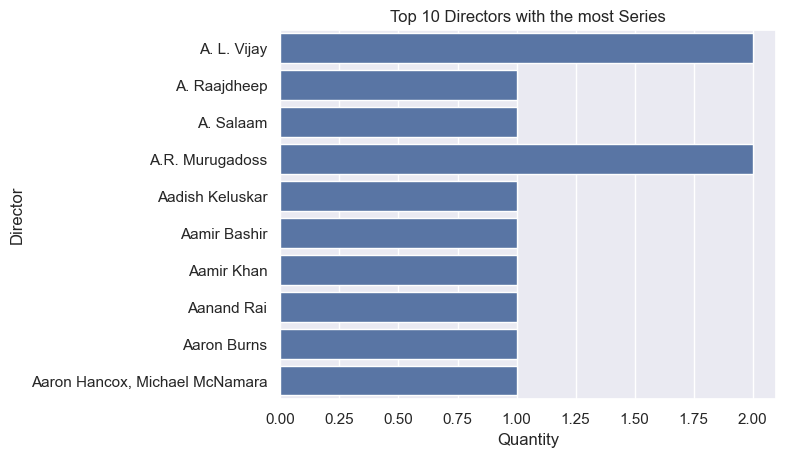

In [298]:
ax = sns.barplot(data = netflix_directors_df, y = "director", x = "quantity");
ax.set(ylabel = "Director",
       xlabel = "Quantity")
plt.title("Top 10 Directors with the most Series");

[Text(0.5, 1.0, "The distribution of rating of Netflix's series"),
 Text(0.5, 0, 'Quantity'),
 Text(0, 0.5, 'Rating')]

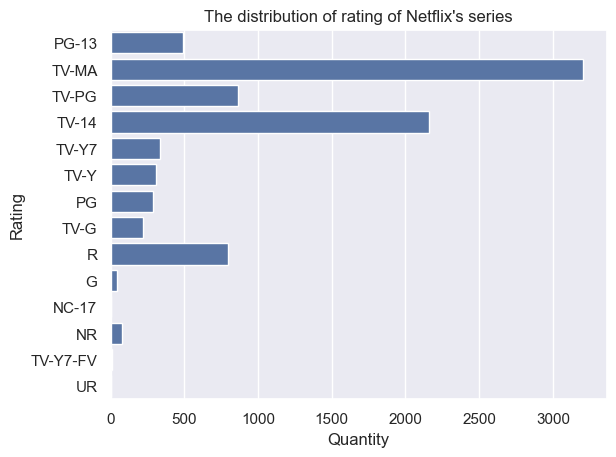

In [299]:
#number of series base on Rating
#netflix_rating_df = (netflix_df.groupby("rating")["quantity"].sum().reset_index()) #cai nay thi nen dung sns.barplot hoac sns.barhplot
#netflix_rating_df.head(10)
ax = sns.countplot(data = netflix_df, y = "rating");
ax.set(title = "The distribution of rating of Netflix's series",
      xlabel = "Quantity",
      ylabel = "Rating")

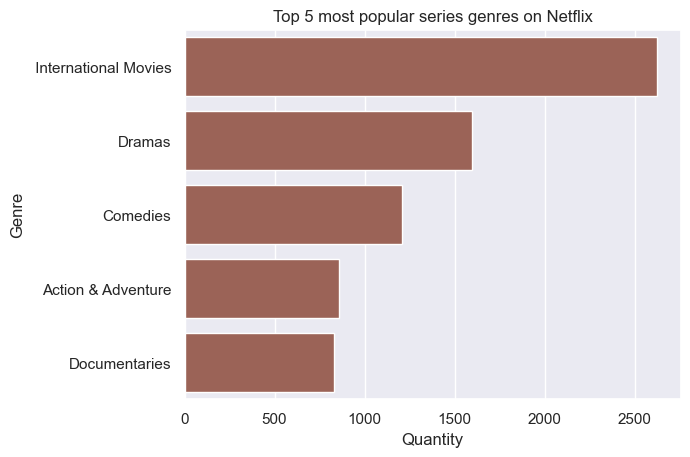

In [300]:
#number of series base on Type (listed_in)
netflix_listed_in_df = netflix_df.copy()
netflix_listed_in_df["listed_in"] = netflix_listed_in_df["listed_in"].str.split(",")
netflix_listed_in_df = netflix_listed_in_df.explode("listed_in")
#netflix_df.head(10)
netflix_listed_in_df['quantity']=1
netflix_listed_in_total_df = (netflix_listed_in_df.groupby("listed_in")["quantity"].sum().reset_index())
#netflix_listed_in_total_df.head(5)
netflix_listed_in_total_df = netflix_listed_in_total_df.sort_values(by = "quantity", ascending = False)
netflix_listed_in_total_df = netflix_listed_in_total_df.head(5)
netflix_listed_in_total_df.head(5)
#netflix_listed_in_total_df.shape
ax = sns.barplot(data = netflix_listed_in_total_df, y = "listed_in", x = "quantity", color = "#A65B4C");
ax.set(title = "Top 5 most popular series genres on Netflix",
      xlabel = "Quantity",
      ylabel = "Genre");

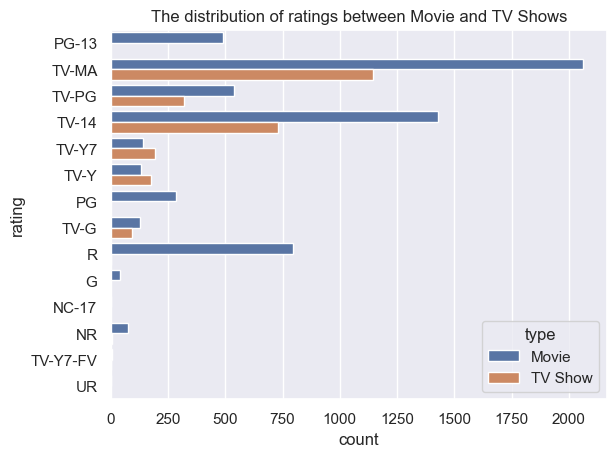

In [301]:
ax = sns.countplot(data = netflix_df, y = "rating", hue = "type");
ax.set(title = "The distribution of ratings between Movie and TV Shows");

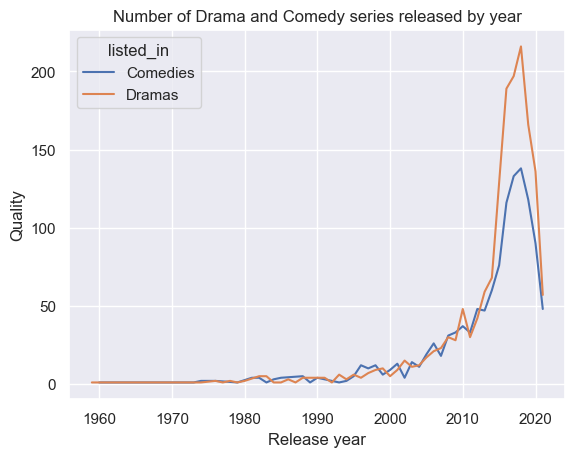

In [302]:
netflix_listed_in_df = netflix_df.copy()
netflix_listed_in_df["listed_in"] = netflix_listed_in_df["listed_in"].str.split(",")
netflix_listed_in_df = netflix_listed_in_df.explode("listed_in")
netflix_listed_in_df["quantity"]=1
#netflix_listed_in_df.head(5)
netflix_listed_in_total_df = (netflix_listed_in_df.groupby(["listed_in","release_year"])["quantity"].sum().reset_index())
#netflix_listed_in_total_df.head(20)
flag = (netflix_listed_in_total_df["listed_in"].isin(["Dramas", "Comedies"])) #check
netflix_listed_in_dramas_comedies_df = netflix_listed_in_total_df[flag]
netflix_listed_in_dramas_comedies_df.head(5)
ax = sns.lineplot(data = netflix_listed_in_dramas_comedies_df, x = "release_year", y = "quantity", hue = "listed_in", marker = '')
ax.set(title = "Number of Drama and Comedy series released by year",
      ylabel = "Quality",
      xlabel = "Release year");